# Wireless Networking and Mobile Computing

### Prerequisites

This Jupyter Notebook has been tested with Visual Studio Code, running in a local Python environment.

**Installs**

In [ ]:
# --- Installs: ensure required packages are available ---
%pip install matplotlib --quiet

**Imports**

In [2]:
# --- Imports: libraries used in this notebook ---
import matplotlib.pyplot as plt
import random

**Declarations**

Set the variables below and run the generation cell. 

- `NUM_PACKETS` is the number of packets to send. 
- `WINDOW_SIZE` is the window size for Go-Back-N and Selective Repeat. 

In [ ]:
# --- Declarations: editable variables for students ---
NUM_PACKETS = ... 
WINDOW_SIZE = ...

### 1.1 Automatic Repeat reQuest (ARQ)

Automatic Repeat reQuest (ARQ) schemes are error-control protocols used in data transmission systems to ensure reliable communication. They operate by detecting errors in transmitted data and retransmitting lost or corrupted packets. ARQ schemes are essential in networking and communication protocols to handle unreliable transmission media. There are three common ARQ schemes:


##### Stop-and-Wait ARQ
Stop-and-Wait ARQ has the sender to send one packet and wait for an acknowledgment (ACK) before sending the next one. If no ACK is received after a timeout, the packet is retransmitted. This approach is simple but inefficient, as the sender is idle during the round-trip delay.

In [3]:
# --- Stop-and-Wait Protocol Simulation ---
def simulate_stop_and_wait(num_packets, loss_prob):
    transmitted = 0
    retransmissions = 0
    successful = 0

    for i in range(num_packets):
        transmitted += 1
        while random.random() < loss_prob:
            retransmissions += 1
            transmitted += 1
        successful += 1

    throughput = successful /  (transmitted+retransmissions*1.2) / 1.4
    return throughput

##### Go-Back-N ARQ
Go-Back-N ARQ has the sender to send multiple packets without waiting for an ACK for each one, but if a packet is lost or corrupted, all subsequent packets are retransmitted (even if they were successfully received). This is known to be more efficient than Stop-and-Wait but suffers from retransmission overhead.

In [4]:
# --- Go-Back-N Protocol Simulation ---
def simulate_go_back_n(num_packets, window_size, loss_prob):
    transmitted = 0
    retransmissions = 0
    successful = 0
    base = 0
    next_seq = 0

    while successful < num_packets:
        while next_seq < base + window_size and next_seq < num_packets:
            transmitted += 1
            if random.random() < loss_prob:
                retransmissions += next_seq - base
                next_seq = base
            else:
                next_seq += 1
                successful += 1
        base = next_seq

    throughput = successful / (transmitted+retransmissions*1.2)
    return throughput

##### Selective Repeat ARQ
Selective Repeat ARQ lets a sender transmit multiple packets, and the receiver acknowledges each one individually. If a packet is lost, only the lost packet is retransmitted, not the subsequent packets. Compared to the other schemes, this is the most efficient, as it minimizes unnecessary retransmissions, but requires a more complex receiver logic.

In [5]:
# --- Selective Repeat Protocol Simulation ---
def simulate_selective_repeat(num_packets, window_size, loss_prob):
    transmitted = 0
    retransmissions = 0
    successful = 0
    base = 0
    acked = [False] * num_packets

    while successful < num_packets:
        for i in range(base, min(base + window_size, num_packets)):
            if not acked[i]:
                transmitted += 1
                if random.random() < loss_prob:
                    retransmissions += 1
                else:
                    acked[i] = True
                    successful += 1
        while base < num_packets and acked[base]:
            base += 1

    throughput = successful / (transmitted+retransmissions*1.2)
    return throughput

### 1.2 Simulation

In [17]:
# --- Simulation ---
LOSS_PROBS = [i / 100 for i in range(0, 51, 5)]  

# Data Collection
sw_throughputs = []
gbn_throughputs = []
sr_throughputs = []

# Run simulations for each loss probability
for prob in LOSS_PROBS:
    sw_throughputs.append(100*simulate_stop_and_wait(NUM_PACKETS, prob))
    gbn_throughputs.append(100*simulate_go_back_n(NUM_PACKETS, WINDOW_SIZE, prob))
    sr_throughputs.append(100*simulate_selective_repeat(NUM_PACKETS, WINDOW_SIZE, prob))

### 1.3 Plot

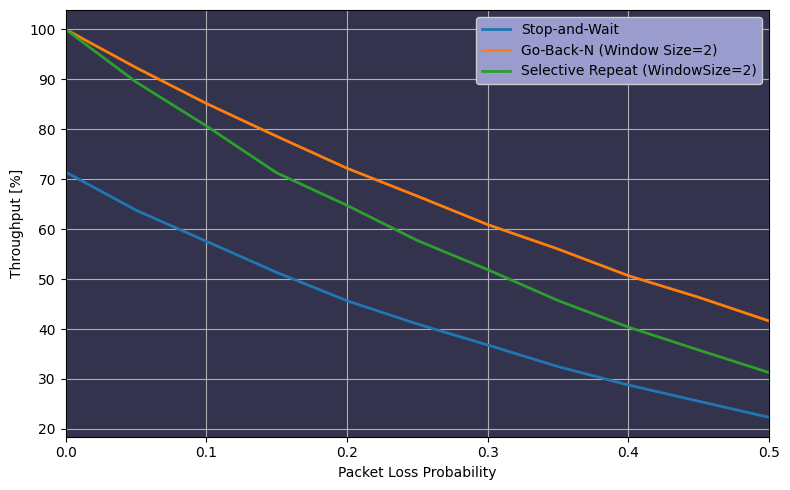

In [18]:
# --- Plotting ---
fig, ax = plt.subplots(figsize=(8, 5))
theLineWidth = 2

ax.cla()
ax.axis([None, None, None, None])

plt.plot(LOSS_PROBS, sw_throughputs, label='Stop-and-Wait', linewidth=theLineWidth)
plt.plot(LOSS_PROBS, gbn_throughputs, label='Go-Back-N (Window Size=' + str(WINDOW_SIZE) + ')', linewidth=theLineWidth)    
plt.plot(LOSS_PROBS, sr_throughputs, label='Selective Repeat (WindowSize=' + str(WINDOW_SIZE) + ')', linewidth=theLineWidth)
plt.xlabel('Packet Loss Probability')
plt.ylabel('Throughput [%]')
plt.grid(True)
plt.xlim(0, 0.5)
ax.set_facecolor((.2, 0.2, 0.3))
plt.legend(fancybox=True, framealpha=1,
           loc="upper right", facecolor=(.6, 0.61, 0.8))
plt.tight_layout()